In [ ]:
print("hello world")

[1] "hello world"


In [ ]:
pkgs <- c("tidyverse", "ggsci", "openxlsx", "googledrive")

In [ ]:
#Estimate time 20 minutes
install.packages(pkgs, dependencies = TRUE, repos = "https://cloud.r-project.org/")

In [ ]:
library(tidyverse)
library(ggsci)
library(openxlsx)
library(googledrive)

In [ ]:
# Define the file path
pheno_path <- "/content/Data/Phenotype.csv"

# Load the dataset
pheno <- read.csv(pheno_path)

# View the first few rows
head(pheno)


,PatientID,Age,Height,Weight,Gender,Tumor_status
,<chr>,<int>,<dbl>,<dbl>,<chr>,<chr>
1,PID-61662,58,164.3,59.2,MALE,Healthy
2,PID-67869,37,187.0,85.0,MALE,Healthy
3,PID-12985,43,165.5,60.0,FEMALE,Cancer
4,PID-39924,75,169.0,82.0,MALE,Healthy
5,PID-78292,61,157.0,65.0,FEMALE,Healthy
6,PID-72554,58,158.0,61.0,FEMALE,Healthy


In [ ]:
library(tidyverse)
library(ggsci)
library(openxlsx)
library(googledrive)

In [ ]:
# Check dimensions (rows, columns)
dim(pheno)

[1] 96  6

In [ ]:
# Display the structure of the dataframe
str(pheno)

'data.frame':	96 obs. of  6 variables:
 $ PatientID   : chr  "PID-61662" "PID-67869" "PID-12985" "PID-39924" ...
 $ Age         : int  58 37 43 75 61 58 56 70 45 82 ...
 $ Height      : num  164 187 166 169 157 ...
 $ Weight      : num  59.2 85 60 82 65 61 77.5 69.5 90 77 ...
 $ Gender      : chr  "MALE" "MALE" "FEMALE" "MALE" ...
 $ Tumor_status: chr  "Healthy" "Healthy" "Cancer" "Healthy" ...


In [ ]:
# Load the Differentially Expressed Gene (DEG) dataset
DEGdata <- read.csv("/content/Data/DEGs.csv")

# Preview the first 6 rows of the data
head(DEGdata)


,Gene_Symbol,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,TSPAN6,2226.57161,0.8308230,0.3358922,2.4734811,1.338039e-02,2.097445e-02
2,TNMD,29.22414,-0.8605165,0.5477937,-1.5708771,1.162112e-01,1.555348e-01
3,DPM1,856.49137,-0.2537967,0.2693102,-0.9423956,3.459902e-01,4.139467e-01
4,SCYL3,612.32154,-0.2363094,0.1484609,-1.5917286,1.114457e-01,1.496098e-01
5,C1orf112,300.43402,-1.1465577,0.1888032,-6.0727655,1.257260e-09,4.180235e-09
6,FGR,356.36644,-0.8618254,0.2923686,-2.9477355,3.201108e-03,5.495173e-03


In [58]:
#Estimate time 25 minutes
# Install and load necessary packages
pkgs_to_install_for_this_task <- c("ggpubr", "patchwork")
new_pkgs_for_this_task <- pkgs_to_install_for_this_task[!(pkgs_to_install_for_this_task %in% installed.packages()["Package"])]
if(length(new_pkgs_for_this_task)) {
  install.packages(new_pkgs_for_this_task, dependencies = TRUE, repos = "https://cloud.r-project.org/")
}

# Load all required libraries
library(tidyverse)
library(ggsci)
library(ggpubr) # For stat_cor
library(patchwork) # For combining plots

# Define the file path
pheno_path <- "/content/Data/Phenotype.csv"

# Load the dataset
pheno <- read.csv(pheno_path)

# --- Define a custom theme for Nature-like formatting ---
theme_nature <- function() {
  theme_classic() +
    theme(
      plot.background = element_rect(fill = "white", color = NA),
      panel.background = element_rect(fill = "white", color = NA),
      panel.grid = element_blank(),
      axis.line = element_line(color = "black", linewidth = 0.5),
      axis.ticks = element_line(color = "black", linewidth = 0.5),
      text = element_text(family = "sans", size = 10),
      plot.title = element_text(hjust = 0.5, face = "bold", size = 12),
      axis.title = element_text(face = "bold", size = 10),
      axis.text = element_text(color = "black", size = 9),
      legend.position = "none",
      plot.margin = unit(c(0.5, 0.5, 0.5, 0.5), "cm")
    )
}

# --- Create Histograms ---
hist_age <- ggplot(pheno, aes(x = Age)) +
  geom_histogram(binwidth = 5, fill = "#1F77B4", color = "black", alpha = 0.8) +
  labs(title = "Distribution of Age", x = "Age", y = "Frequency") +
  theme_nature()

hist_weight <- ggplot(pheno, aes(x = Weight)) +
  geom_histogram(binwidth = 5, fill = "#2CA02C", color = "black", alpha = 0.8) +
  labs(title = "Distribution of Weight", x = "Weight (kg)", y = "Frequency") +
  theme_nature()

hist_height <- ggplot(pheno, aes(x = Height)) +
  geom_histogram(binwidth = 5, fill = "#D62728", color = "black", alpha = 0.8) +
  labs(title = "Distribution of Height", x = "Height (cm)", y = "Frequency") +
  theme_nature()

# --- Create Scatter Plots ---
scatter_age_weight <- ggplot(pheno, aes(x = Age, y = Weight)) +
  geom_point(color = "#FF7F0E", alpha = 0.7, size = 2) +
  geom_smooth(method = "lm", se = FALSE, color = "black", linewidth = 0.5) +
  # FIXED LINE BELOW: Removed the stray backtick and simplified the label format
  stat_cor(method = "pearson", label.x.npc = "left", label.y.npc = "top", size = 4) +
  labs(title = "Age vs Weight", x = "Age", y = "Weight (kg)") +
  theme_nature()

scatter_height_weight <- ggplot(pheno, aes(x = Height, y = Weight)) +
  geom_point(color = "#9467BD", alpha = 0.7, size = 2) +
  geom_smooth(method = "lm", se = FALSE, color = "black", linewidth = 0.5) +
  # FIXED LINE BELOW: Removed the stray backtick and simplified the label format
  stat_cor(method = "pearson", label.x.npc = "left", label.y.npc = "top", size = 4) +
  labs(title = "Height vs Weight", x = "Height (cm)", y = "Weight (kg)") +
  theme_nature()

# --- Combine Plots using patchwork ---
combined_plot <- (hist_age | hist_weight | hist_height) /
                 (scatter_age_weight | scatter_height_weight) +
  plot_annotation(tag_levels = 'A') &
  theme(plot.tag = element_text(size = 14, face = "bold", family = "sans"))
##Please check the path. If not set to the Data folder, you may need to specify"
# --- Save the combined figure as a high-resolution PDF ---
ggsave("/content/Data/phenotype_plots.pdf", plot = combined_plot,
       width = 12, height = 8, units = "in", dpi = 300, device = "pdf")

# Provide feedback
print("Success! The combined publication-quality figure 'phenotype_plots.pdf' has been generated and saved.")

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


[1] "Success! The combined publication-quality figure 'phenotype_plots.pdf' has been generated and saved."


In [61]:

# Install and load necessary packages
pkgs_to_install_for_this_task <- c("ggpubr", "patchwork", "ggsci")
new_pkgs_for_this_task <- pkgs_to_install_for_this_task[!(pkgs_to_install_for_this_task %in% installed.packages()["Package"])]
if(length(new_pkgs_for_this_task)) {
  install.packages(new_pkgs_for_this_task, dependencies = TRUE, repos = "https://cloud.r-project.org/")
}

# Load all required libraries
library(tidyverse)
library(ggsci)   # For NPG color palette
library(ggpubr)  # For stat_compare_means (Wilcoxon test and p-value display)
library(patchwork) # For combining plots

# Define the file path
pheno_path <- "/content/Data/Phenotype.csv"

# Load the dataset
pheno <- read.csv(pheno_path)

# Ensure Tumor_status is a factor for proper grouping
pheno$Tumor_status <- factor(pheno$Tumor_status, levels = c("Healthy", "Cancer"))

# --- Define a custom theme for Nature-like formatting ---
theme_nature_comparison <- function() {
  theme_classic() + # Start with a classic theme for a good base
    theme(
      plot.background = element_rect(fill = "white", color = NA), # White plot background
      panel.background = element_rect(fill = "white", color = NA), # White panel background
      panel.grid = element_blank(), # Remove grid lines
      axis.line = element_line(color = "black", linewidth = 0.5), # Solid black axis lines
      axis.ticks = element_line(color = "black", linewidth = 0.5), # Solid black axis ticks
      text = element_text(family = "sans", face = "bold", color = "black", size = 12), # Arial (sans-serif), bold, black, readable size
      plot.title = element_text(hjust = 0.5, face = "bold", size = 14), # Centered, bold title
      axis.title = element_text(face = "bold", size = 12), # Bold axis titles
      axis.text = element_text(color = "black", face = "bold", size = 10), # Black, bold axis text
      legend.title = element_blank(), # Remove legend title
      legend.position = "top", # Position legend at the top
      legend.text = element_text(size = 10, face = "bold"),
      plot.margin = unit(c(0.5, 0.5, 0.5, 0.5), "cm") # Add some margin around the plot
    )
}

# --- Function to create Box-Violin plots with Wilcoxon test ---
create_box_violin_plot <- function(data, y_var, y_label) {
  ggplot(data, aes_string(x = "Tumor_status", y = y_var, fill = "Tumor_status")) +
    geom_violin(trim = FALSE, alpha = 0.6, linewidth = 0.5) + # Violin plot for distribution
    geom_boxplot(width = 0.2, fill = "white", outlier.shape = NA, linewidth = 0.5) + # Narrow white boxplot inside
    geom_jitter(color = "black", size = 0.8, alpha = 0.3, width = 0.15) + # Individual data points
    scale_fill_npg() + # Nature Publishing Group color palette
    labs(title = paste("Comparison of", y_label, "by Tumor Status"),
         x = "Tumor Status",
         y = y_label) +
    stat_compare_means(comparisons = list(c("Healthy", "Cancer")),
                       method = "wilcox.test",
                       label.y = max(data[[y_var]]) * 1.05, # Position p-value above max value
                       label = "p.format",
                       size = 4, # Font size for p-value
                       face = "bold", # Make p-value bold
                       color = "black") + # Make p-value black
    theme_nature_comparison()
}

# --- Create the three individual plots ---
plot_age <- create_box_violin_plot(pheno, "Age", "Age (Years)")
plot_weight <- create_box_violin_plot(pheno, "Weight", "Weight (kg)")
plot_height <- create_box_violin_plot(pheno, "Height", "Height (cm)")

# --- Combine plots side-by-side using patchwork ---
combined_comparison_plot <- plot_age + plot_weight + plot_height +
  plot_annotation(tag_levels = 'A') &
  theme(plot.tag = element_text(size = 14, face = "bold", family = "sans")) # Style for the subplot tags

# --- Save the combined figure as a high-resolution PDF ---
ggsave("/content/Data/phenotype_comparison_plots.pdf", plot = combined_comparison_plot,
       width = 16, height = 7, units = "in", dpi = 300, device = "pdf")

# Provide feedback
print("Success! The combined comparison figure 'phenotype_comparison_plots.pdf' has been generated and saved.")
print("It includes three box-violin plots for Age, Weight, and Height, comparing 'Cancer' vs 'Healthy' groups.")
print("Each plot shows the p-value from a Wilcoxon test, uses the NPG color palette, and is formatted in a Nature-like style with bold, black text.")


Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



[1] "Success! The combined comparison figure 'phenotype_comparison_plots.pdf' has been generated and saved."
[1] "It includes three box-violin plots for Age, Weight, and Height, comparing 'Cancer' vs 'Healthy' groups."
[1] "Each plot shows the p-value from a Wilcoxon test, uses the NPG color palette, and is formatted in a Nature-like style with bold, black text."


In [62]:
#**Estimate time 10 mins**

# Install and load necessary packages for this task
pkgs_to_install_for_this_task <- c("ggrepel")
new_pkgs_for_this_task <- pkgs_to_install_for_this_task[!(pkgs_to_install_for_this_task %in% installed.packages()["Package"])]
if(length(new_pkgs_for_this_task)) {
  install.packages(new_pkgs_for_this_task, dependencies = TRUE, repos = "https://cloud.r-project.org/")
}

# Load all required libraries
library(tidyverse)
library(ggsci)
library(ggrepel) # For non-overlapping text labels

# Load the Differentially Expressed Gene (DEG) dataset
DEGdata <- read.csv("/content/Data/DEGs.csv")

# --- Data Preparation for Volcano Plot ---
# Define significance thresholds
log2FC_threshold <- 1
p_value_threshold <- 0.05

# Calculate -log10(padj) for plotting
DEGdata$log10_padj <- -log10(DEGdata$padj)

# Create a 'Direction' column for coloring
DEGdata <- DEGdata %>%
  mutate(Direction = case_when(
    padj < p_value_threshold & log2FoldChange > log2FC_threshold ~ "Upregulated",
    padj < p_value_threshold & log2FoldChange < -log2FC_threshold ~ "Downregulated",
    TRUE ~ "Not significant"
  ))

# Identify the top 5 most statistically significant genes (smallest padj)
top_genes <- DEGdata %>%
  filter(Direction != "Not significant") %>%
  arrange(padj) %>%
  head(5)

# --- Define a custom theme for Nature-like formatting ---
theme_nature_volcano <- function() {
  theme_classic() + # Start with a classic theme for a good base
    theme(
      plot.background = element_rect(fill = "white", color = NA), # White plot background
      panel.background = element_rect(fill = "white", color = NA), # White panel background
      panel.grid = element_blank(), # Remove grid lines
      axis.line = element_line(color = "black", linewidth = 0.5), # Solid black axis lines
      axis.ticks = element_line(color = "black", linewidth = 0.5), # Solid black axis ticks
      text = element_text(family = "sans", size = 10), # Generic sans-serif font (e.g., Arial, Helvetica)
      plot.title = element_text(hjust = 0.5, face = "bold", size = 12), # Centered, bold title
      axis.title = element_text(face = "bold", size = 10), # Bold axis titles
      axis.text = element_text(color = "black", size = 9),
      legend.title = element_blank(), # Remove legend title
      legend.position = "top", # Position legend at the top
      legend.text = element_text(size = 9),
      plot.margin = unit(c(0.5, 0.5, 0.5, 0.5), "cm") # Add some margin around the plot
    )
}

# --- Create the Volcano Plot ---
volcano_plot <- ggplot(DEGdata, aes(x = log2FoldChange, y = log10_padj, color = Direction)) +
  geom_point(alpha = 0.8, size = 1) +
  scale_color_manual(values = c("Upregulated" = "#E41A1C",
                                "Downregulated" = "#377EB8",
                                "Not significant" = "gray80")) + # Nature-like colors
  geom_hline(yintercept = -log10(p_value_threshold), linetype = "dashed", color = "black", linewidth = 0.4) +
  geom_vline(xintercept = c(-log2FC_threshold, log2FC_threshold), linetype = "dashed", color = "black", linewidth = 0.4) +
  geom_text_repel(data = top_genes, aes(label = Gene_Symbol),
                  size = 4, fontface = "bold", box.padding = 0.5, point.padding = 0.5,
                  segment.color = 'black', min.segment.length = 0, max.overlaps = Inf) + # Label top genes
  labs(title = "Volcano Plot",
       x = "Log2 Fold Change",
       y = "-log10(Adjusted P-value)") +
  theme_nature_volcano()

# --- Save the Volcano Plot as a high-resolution PDF ---
ggsave("/content/Data/volcano_plot.pdf", plot = volcano_plot,
       width = 8, height = 7, units = "in", dpi = 300, device = "pdf")

# Provide feedback
print("Success! The professional Volcano Plot 'volcano_plot.pdf' has been generated and saved with bold and clear gene labels.")


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘rsvg’


Warning message in install.packages(new_pkgs_for_this_task, dependencies = TRUE, :
“installation of package ‘rsvg’ had non-zero exit status”
Warning message:
“Removed 363 rows containing missing values or values outside the scale range
(`geom_point()`).”


[1] "Success! The professional Volcano Plot 'volcano_plot.pdf' has been generated and saved with bold and clear gene labels."


'select()' returned 1:many mapping between keys and columns

Warning message in bitr(significant_genes, fromType = "SYMBOL", toType = "ENTREZID", :
“2.03% of input gene IDs are fail to map...”


[1] "Success! The professional pathway enrichment plot has been generated and saved."


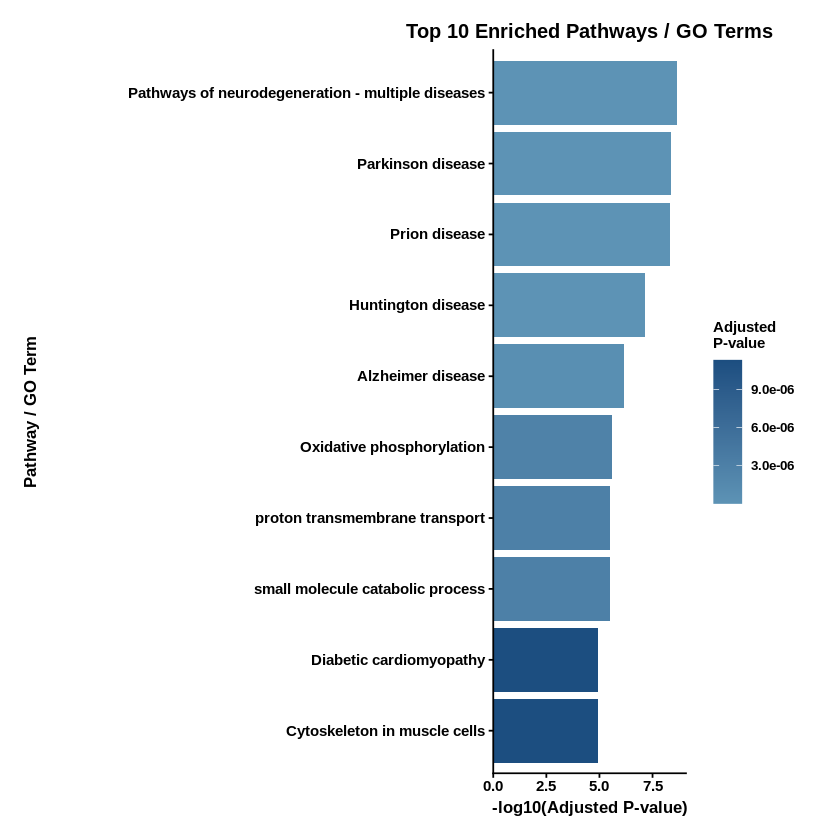

In [63]:
#**Estimated time=10min**

# Load all required libraries
library(tidyverse)
library(clusterProfiler)
library(org.Hs.eg.db) # For human gene annotations
library(ggplot2)
library(dplyr)
library(ggsci) # For NPG color palette

# Load the Differentially Expressed Gene (DEG) dataset
DEGdata <- read.csv("/content/Data/DEGs.csv")

# --- 1. Identify Significant Genes ---
# Define significance thresholds
log2FC_threshold <- 1
p_value_threshold <- 0.05

significant_genes <- DEGdata %>%
  filter(padj < p_value_threshold & abs(log2FoldChange) > log2FC_threshold) %>%
  pull(Gene_Symbol) # Extract Gene Symbols of significant genes

# Ensure there are significant genes to proceed
if (length(significant_genes) == 0) {
  stop("No significant genes found based on the defined thresholds. Adjust thresholds or check data.")
}

# --- 2. Gene ID Conversion: Gene Symbol to Entrez ID ---
# Map gene symbols to Entrez IDs
entrez_ids <- bitr(significant_genes,
                   fromType = "SYMBOL",
                   toType = "ENTREZID",
                   OrgDb = org.Hs.eg.db)

# Extract unique Entrez IDs
genes_for_enrichment <- unique(entrez_ids$ENTREZID)

# --- 3. Perform Enrichment Analysis ---

# KEGG Pathway Enrichment (Fixed: Removed 'readable = TRUE')
kegg_enrichment <- enrichKEGG(gene = genes_for_enrichment,
                              organism = 'hsa',
                              pvalueCutoff = p_value_threshold,
                              qvalueCutoff = 0.2)

# Make KEGG readable (Convert Entrez IDs back to Gene Symbols)
if (!is.null(kegg_enrichment)) {
  kegg_enrichment <- setReadable(kegg_enrichment, OrgDb = org.Hs.eg.db, keyType="ENTREZID")
}

# GO Biological Process (BP) Enrichment
gobp_enrichment <- enrichGO(gene = genes_for_enrichment,
                             OrgDb = org.Hs.eg.db,
                             ont = "BP",
                             pvalueCutoff = p_value_threshold,
                             qvalueCutoff = 0.2,
                             readable = TRUE)

# GO Molecular Function (MF) Enrichment
gomf_enrichment <- enrichGO(gene = genes_for_enrichment,
                             OrgDb = org.Hs.eg.db,
                             ont = "MF",
                             pvalueCutoff = p_value_threshold,
                             qvalueCutoff = 0.2,
                             readable = TRUE)

# --- 4. Combine and Filter Results for Top 10 ---

# Convert results to data frames and add a 'Source' column safely
kegg_df <- if(is.null(kegg_enrichment)) data.frame() else as.data.frame(kegg_enrichment) %>% mutate(Source = "KEGG")
gobp_df <- if(is.null(gobp_enrichment)) data.frame() else as.data.frame(gobp_enrichment) %>% mutate(Source = "GO:BP")
gomf_df <- if(is.null(gomf_enrichment)) data.frame() else as.data.frame(gomf_enrichment) %>% mutate(Source = "GO:MF")

# Combine all significant results
combined_results <- bind_rows(kegg_df, gobp_df, gomf_df) %>%
  filter(p.adjust < p_value_threshold) # Filter again based on adjusted p-value

# Select the top 10 most significant results based on p.adjust
top10_results <- combined_results %>%
  arrange(p.adjust) %>%
  head(10)

# Ensure there are results to plot
if (nrow(top10_results) == 0) {
  stop("No significant pathways/GO terms found after enrichment analysis. Adjust thresholds or check data.")
}

# --- 5. Create Bar Chart ---

# Define a custom theme for Nature-like formatting
theme_nature_pathway <- function() {
  theme_classic() +
    theme(
      plot.background = element_rect(fill = "white", color = NA),
      panel.background = element_rect(fill = "white", color = NA),
      panel.grid = element_blank(),
      axis.line = element_line(color = "black", linewidth = 0.5),
      axis.ticks = element_line(color = "black", linewidth = 0.5),
      text = element_text(family = "sans", face = "bold", color = "black", size = 10),
      plot.title = element_text(hjust = 0.5, face = "bold", size = 12),
      axis.title = element_text(face = "bold", size = 10),
      axis.text.x = element_text(color = "black", face = "bold", size = 9),
      axis.text.y = element_text(color = "black", face = "bold", size = 9),
      legend.title = element_text(face = "bold", size = 9),
      legend.text = element_text(size = 8),
      legend.position = "right",
      plot.margin = unit(c(0.5, 0.5, 0.5, 0.5), "cm")
    )
}

# Order the pathways by significance (p.adjust) for plotting
top10_results$Description <- factor(top10_results$Description,
                                    levels = rev(top10_results$Description[order(top10_results$p.adjust)]))

pathway_plot <- ggplot(top10_results, aes(x = Description, y = -log10(p.adjust), fill = p.adjust)) +
  geom_bar(stat = "identity") +
  coord_flip() +
  scale_fill_gradient(low = "#5D93B5", high = "#1C4E80", name = "Adjusted \nP-value") +
  labs(title = "Top 10 Enriched Pathways / GO Terms",
       x = "Pathway / GO Term",
       y = "-log10(Adjusted P-value)") +
  theme_nature_pathway() +
  scale_y_continuous(expand = expansion(mult = c(0, 0.05)))

print(pathway_plot)

# --- 6. Save the plot as a high-resolution PDF ---
ggsave("/content/Data/pathway_enrichment_plot.pdf", plot = pathway_plot,
       width = 10, height = 7, units = "in", dpi = 300, device = "pdf")

print("Success! The professional pathway enrichment plot has been generated and saved.")


[1] "Success! The bubble plot categorized by Source has been generated and saved."


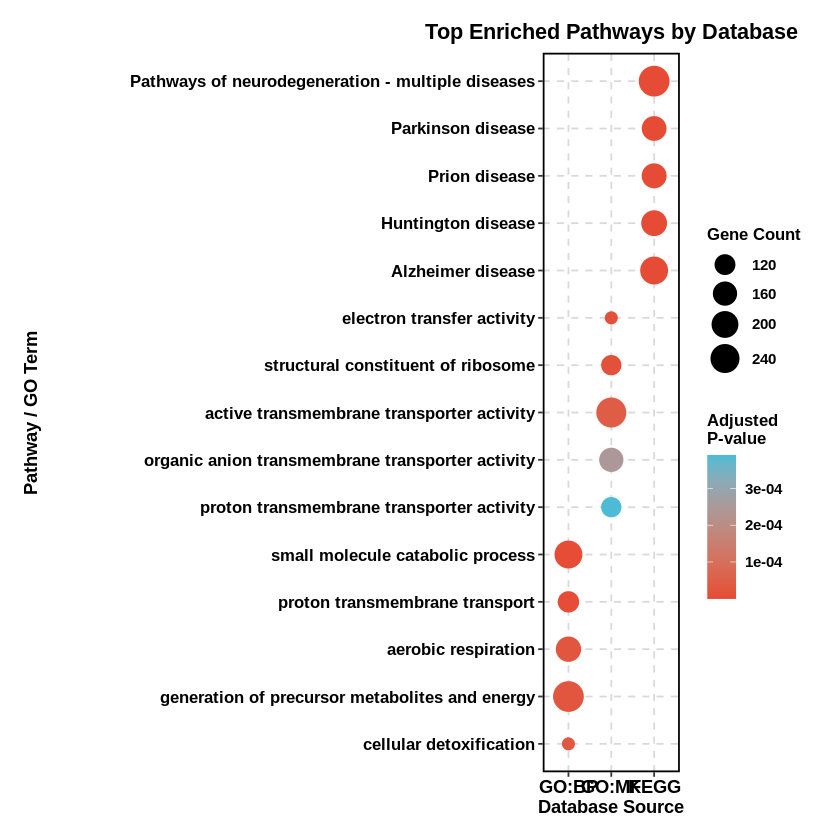

In [65]:
# Load required libraries
library(tidyverse)
library(ggplot2)

# Assuming your enrichment results are stored in a dataframe called `combined_results`
# (which matches the clipboard data you provided)

# --- 1. Filter and extract Top 5 terms PER SOURCE ---
top_results_by_source <- combined_results %>%
  filter(p.adjust < 0.05) %>%
  group_by(Source) %>%
  arrange(p.adjust) %>%
  slice_head(n = 5) %>% # Take the top 5 most significant from KEGG, GO:BP, GO:MF, etc.
  ungroup()

# Ensure the Description is ordered by Source and then by p.adjust for neat plotting
top_results_by_source <- top_results_by_source %>%
  arrange(Source, desc(p.adjust)) %>%
  mutate(Description = factor(Description, levels = unique(Description)))

# --- 2. Define Publication-Ready Theme ---
theme_nature_source_bubble <- function() {
  theme_bw() + # Clean white background with a border
    theme(
      panel.grid.major = element_line(color = "grey85", linetype = "dashed", linewidth = 0.5), # Faint dashed grid
      panel.grid.minor = element_blank(),
      panel.border = element_rect(color = "black", fill = NA, linewidth = 1),
      text = element_text(family = "sans", face = "bold", color = "black", size = 10),
      plot.title = element_text(hjust = 0.5, face = "bold", size = 13),
      axis.title = element_text(face = "bold", size = 11),
      axis.text.x = element_text(color = "black", face = "bold", size = 11), # Larger X-axis text for Source
      axis.text.y = element_text(color = "black", face = "bold", size = 10),
      legend.title = element_text(face = "bold", size = 10),
      legend.text = element_text(size = 9),
      legend.position = "right",
      plot.margin = unit(c(0.5, 0.5, 0.5, 0.5), "cm")
    )
}

# --- 3. Create the Bubble Plot ---
source_bubble_plot <- ggplot(top_results_by_source, aes(x = Source, y = Description)) +
  geom_point(aes(size = Count, color = p.adjust)) +
  scale_color_gradient(low = "#E64B35", high = "#4DBBD5", name = "Adjusted\nP-value") + # NPG Red to Blue
  scale_size_continuous(name = "Gene Count", range = c(3, 8)) + # Adjust bubble size range for visibility
  labs(title = "Top Enriched Pathways by Database",
       x = "Database Source",
       y = "Pathway / GO Term") +
  theme_nature_source_bubble()

print(source_bubble_plot)

# --- 4. Save the Plot ---
ggsave("/content/Data/pathway_source_bubble_plot.pdf", plot = source_bubble_plot,
       width = 10, height = 8, units = "in", dpi = 300, device = "pdf")

print("Success! The bubble plot categorized by Source has been generated and saved.")
